# House Price Prediction — Data Audit

## Objective

This notebook performs the initial data audit for the Kaggle House Prices — Advanced Regression Techniques competition.

The objective is to understand the raw dataset before preprocessing and modeling by examining:

- Dataset structure and schema
- Feature semantics and data types
- Missing-value patterns
- Duplicate records and identifiers
- Data consistency and suspicious observations
- Train/test compatibility
- Target variable distribution
- Potential outliers and influential observations

### Audit Principles

1. Raw data is treated as immutable.
2. Missing values are interpreted using the provided domain description.
3. Structural absence is distinguished from unknown information.
4. Potential outliers are investigated rather than automatically removed.
5. No model-driven preprocessing decisions are made in this notebook.
6. All important findings are documented for use in later phases.

> **Output of this phase:** A documented data-audit report and preprocessing recommendations.

## 1. Imports & Project Configuration

The project configuration is loaded from `configs/config.yaml` so that paths, the target variable, and the random seed are not hard-coded inside the notebook.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config
from src.utils import set_seed

# Load project configuration
config = load_config()

# Reproducibility
set_seed(config["project"]["random_seed"])

# Paths and settings
TARGET = config["data"]["target_column"]
RAW_DIR = PROJECT_ROOT / config["data"]["raw_dir"]

TRAIN_PATH = RAW_DIR / config["data"]["train_file"]
TEST_PATH = RAW_DIR / config["data"]["test_file"]

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DIR)
print("Target column:", TARGET)
print("Random seed:", config["project"]["random_seed"])

Project root: c:\Users\Haroon Work\Desktop\Brototype\Projects\Regression - House Price Prediction\house-price-prediction
Raw data directory: c:\Users\Haroon Work\Desktop\Brototype\Projects\Regression - House Price Prediction\house-price-prediction\data\raw
Target column: SalePrice
Random seed: 42


## 2. Load Raw Data

The raw training and test datasets are loaded directly from `data/raw`.

The original files will not be modified during the audit.

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (1460, 81)
Test shape:  (1459, 80)


### Initial Dataset Structure

The training dataset contains the target variable `SalePrice`, while the test dataset contains the same predictor columns without the target.

The initial dimensions are:

- Training set: **1,460 rows × 81 columns**
- Test set: **1,459 rows × 80 columns**

## 3. Schema Audit

### Objective

Verify that the training and test datasets have compatible schemas and identify the target column.

The training and test datasets should contain the same predictor variables, with `SalePrice` appearing only in the training data.

In [3]:
train_columns = set(train_df.columns)
test_columns = set(test_df.columns)

train_only = sorted(train_columns - test_columns)
test_only = sorted(test_columns - train_columns)
common_columns = sorted(train_columns & test_columns)

print("Columns only in train:", train_only)
print("Columns only in test:", test_only)
print("Number of common columns:", len(common_columns))

Columns only in train: ['SalePrice']
Columns only in test: []
Number of common columns: 80


### Finding

The datasets contain:

- **80 common predictor columns**
- `SalePrice` is the only training-only column
- No test-only columns

Therefore, the train/test schema is structurally compatible.

## 4. Dataset Profile

This section summarizes the structure of the training dataset, including data types, missing values, and feature cardinality.

Because pandas storage types do not necessarily represent the semantic role of a feature, semantic classification will be handled separately.

In [4]:
feature_columns = train_df.columns.drop(TARGET)

feature_inventory = pd.DataFrame({
    "dtype": train_df[feature_columns].dtypes.astype(str),
    "missing_count": train_df[feature_columns].isna().sum(),
    "missing_pct": (
        train_df[feature_columns].isna().mean() * 100
    ).round(2),
    "unique_values": train_df[feature_columns].nunique(dropna=False)
})

feature_inventory

,dtype,missing_count,missing_pct,unique_values
Id,int64,0,0.00,1460
MSSubClass,int64,0,0.00,15
MSZoning,str,0,0.00,5
LotFrontage,float64,259,17.74,111
LotArea,int64,0,0.00,1073
...,...,...,...,...
MiscVal,int64,0,0.00,21
MoSold,int64,0,0.00,12
YrSold,int64,0,0.00,5
SaleType,str,0,0.00,9


## 5. Feature Semantics

A pandas dtype does not necessarily represent the statistical meaning of a feature.

For example:

- `MSSubClass` is stored as an integer but represents a dwelling-type code.
- `OverallQual` is stored as an integer but represents an ordinal quality rating.
- `YearBuilt` represents a year.
- `MoSold` represents the month of sale.
- `Id` is an identifier rather than a property characteristic.

Therefore, features will be interpreted using both their storage type and the domain definitions provided in `data_description.txt`.

### Initial Semantic Categories

| Semantic category | Examples |
|---|---|
| Identifier | `Id` |
| Nominal categorical | `Neighborhood`, `MSZoning`, `RoofStyle` |
| Ordinal categorical | `OverallQual`, `OverallCond`, `ExterQual` |
| Continuous numerical | `LotArea`, `GrLivArea`, `MasVnrArea` |
| Count/discrete numerical | `BedroomAbvGr`, `Fireplaces`, `GarageCars` |
| Temporal | `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `MoSold`, `YrSold` |

This classification is an audit-level semantic interpretation. Exact preprocessing treatment will be determined in later experiments.

## 6. Missing-Value Audit

### Objective

Determine whether missing values represent:

1. Structural absence of a property feature.
2. Unknown or unrecorded information.
3. Potentially inconsistent information.

Missing values are **not imputed in this notebook**.

The domain definitions in `data_description.txt` are used to interpret missingness rather than treating every `NaN` as the same type of problem.

In [5]:
missing_summary = (
    train_df[feature_columns]
    .isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "missing_count": missing_summary,
    "missing_pct": (
        missing_summary / len(train_df) * 100
    ).round(2)
})

missing_report

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### 6.1 Structural Missingness

Several features use missing values to represent the absence of a physical feature.

Examples from the domain description include:

- `PoolQC` → No pool
- `Alley` → No alley access
- `Fence` → No fence
- `FireplaceQu` → No fireplace
- Garage-related categorical features → No garage
- Basement-related categorical features → No basement
- `MiscFeature` → No miscellaneous feature

These values should therefore not be treated as ordinary missing observations during preprocessing.

In [6]:
garage_missing = train_df["GarageYrBlt"].isna()

garage_validation = {
    "missing_GarageYrBlt": garage_missing.sum(),
    "missing_with_GarageCars_positive": (
        garage_missing & (train_df["GarageCars"] > 0)
    ).sum(),
    "missing_with_GarageArea_positive": (
        garage_missing & (train_df["GarageArea"] > 0)
    ).sum(),
}

garage_validation

{'missing_GarageYrBlt': np.int64(81),
 'missing_with_GarageCars_positive': np.int64(0),
 'missing_with_GarageArea_positive': np.int64(0)}

**Finding:** All 81 observations with missing `GarageYrBlt` also have zero garage capacity and zero garage area.

This supports interpreting the garage-related missing values as **structural absence of a garage**.

In [7]:
basement_missing = train_df["BsmtQual"].isna()

basement_validation = {
    "missing_BsmtQual": basement_missing.sum(),
    "TotalBsmtSF_positive": (
        basement_missing & (train_df["TotalBsmtSF"] > 0)
    ).sum(),
    "BsmtFinSF1_positive": (
        basement_missing & (train_df["BsmtFinSF1"] > 0)
    ).sum(),
    "BsmtFinSF2_positive": (
        basement_missing & (train_df["BsmtFinSF2"] > 0)
    ).sum(),
    "BsmtUnfSF_positive": (
        basement_missing & (train_df["BsmtUnfSF"] > 0)
    ).sum(),
}

basement_validation

{'missing_BsmtQual': np.int64(37),
 'TotalBsmtSF_positive': np.int64(0),
 'BsmtFinSF1_positive': np.int64(0),
 'BsmtFinSF2_positive': np.int64(0),
 'BsmtUnfSF_positive': np.int64(0)}

**Finding:** All 37 observations with missing `BsmtQual` have zero basement area and zero finished/unfinished basement area.

This supports interpreting the basement-related missing values as **structural absence of a basement**.

### 6.2 Special Missingness Cases

Some features require more careful treatment because their missing values do not have a simple structural interpretation.

In [8]:
masvnr_missing = train_df["MasVnrType"].isna()

masvnr_summary = {
    "missing_MasVnrType": masvnr_missing.sum(),
    "area_zero": (
        masvnr_missing & (train_df["MasVnrArea"] == 0)
    ).sum(),
    "area_missing": (
        masvnr_missing & train_df["MasVnrArea"].isna()
    ).sum(),
    "area_positive": (
        masvnr_missing & (train_df["MasVnrArea"] > 0)
    ).sum(),
}

masvnr_summary

{'missing_MasVnrType': np.int64(872),
 'area_zero': np.int64(859),
 'area_missing': np.int64(8),
 'area_positive': np.int64(5)}

**Finding:** `MasVnrType` has 872 missing values.

- 859 have `MasVnrArea = 0`
- 8 have `MasVnrArea` missing
- 5 have `MasVnrArea > 0`

The five observations with positive masonry veneer area demonstrate that missing `MasVnrType` cannot universally be interpreted as "No masonry veneer."

**Recommendation:** evaluate the treatment of this feature empirically during preprocessing.

### 6.3 LotFrontage

`LotFrontage` has 259 missing observations (17.74%).

Because the feature represents the linear feet of street connected to a property, missingness does not imply zero frontage.

Neighborhood-level analysis is therefore relevant.

In [9]:
lot_frontage_by_neighborhood = (
    train_df.groupby("Neighborhood")["LotFrontage"]
    .agg(["count", "median", "mean", "std"])
    .sort_values("median")
)

lot_frontage_by_neighborhood

,count,median,mean,std
Neighborhood,,,,
BrDale,16,21.0,21.562500,1.209339
MeadowV,15,21.0,27.800000,10.107988
NPkVill,7,24.0,32.285714,14.150551
Blueste,2,24.0,24.000000,0.000000
Blmngtn,14,43.0,47.142857,4.990100
BrkSide,51,52.0,57.509804,15.528519
IDOTRR,34,60.0,62.500000,18.282712
OldTown,109,60.0,62.788991,18.170017
SWISU,23,60.0,58.913043,10.539592


**Finding:** Observed neighborhood medians vary substantially, approximately from 21 ft to 91 ft.

This suggests that a neighborhood-aware imputation strategy may preserve more information than a single global median.

**Recommendation:** compare neighborhood-based imputation against simpler alternatives during cross-validation.

## 7. Duplicate & Identifier Audit

The audit checks both exact duplicate records and duplicate identifiers.

These are separate checks because two rows can be different while still incorrectly sharing the same identifier.

In [10]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

print("\nDuplicate IDs in train:", train_df["Id"].duplicated().sum())
print("Duplicate IDs in test:", test_df["Id"].duplicated().sum())

print("\nTrain ID range:", train_df["Id"].min(), "to", train_df["Id"].max())
print("Test ID range:", test_df["Id"].min(), "to", test_df["Id"].max())

print(
    "\nTrain/Test ID overlap:",
    len(set(train_df["Id"]) & set(test_df["Id"]))
)

Duplicate rows in train: 0
Duplicate rows in test: 0

Duplicate IDs in train: 0
Duplicate IDs in test: 0

Train ID range: 1 to 1460
Test ID range: 1461 to 2919

Train/Test ID overlap: 0


### Finding

- Exact duplicate rows in train: **0**
- Exact duplicate rows in test: **0**
- Duplicate train IDs: **0**
- Duplicate test IDs: **0**
- Train IDs: **1–1460**
- Test IDs: **1461–2919**
- Train/test ID overlap: **0**

`Id` is a sequential identifier rather than a property characteristic.

**Recommendation:** exclude `Id` from the predictive feature set in later modeling unless a controlled experiment provides a specific justification for retaining it.

## 8. Train/Test Compatibility

The preprocessing pipeline will be fitted using the training data and then applied to the test data.

We therefore check whether the test set contains categorical levels that never appear in training.

In [11]:
categorical_columns = train_df.select_dtypes(
    include=["object", "string"]
).columns

test_only_categories = {}

for column in categorical_columns:
    train_categories = set(train_df[column].dropna().unique())
    test_categories = set(test_df[column].dropna().unique())

    unseen = test_categories - train_categories

    if unseen:
        test_only_categories[column] = sorted(unseen)

test_only_categories

{}

### Finding

No categorical values were found in the test set that are absent from the training set.

This reduces the risk of train/test category mismatch during categorical encoding.

### 8.2 Numerical Train/Test Distribution Audit

Categorical compatibility alone does not guarantee that the training and test datasets come from comparable distributions.

For numerical features, we compare:

- Minimum and maximum values
- Mean
- Median
- Standard deviation

The purpose is to identify potentially meaningful distribution shifts that may require investigation.

This is an audit only. No feature is removed or transformed based solely on this comparison.

In [12]:
numerical_columns = train_df.select_dtypes(
    include=["int64", "float64"]
).columns.drop(TARGET)

train_numeric = train_df[numerical_columns].describe().T
test_numeric = test_df[numerical_columns].describe().T

numerical_distribution = pd.DataFrame({
    "train_mean": train_numeric["mean"],
    "test_mean": test_numeric["mean"],
    "train_median": train_numeric["50%"],
    "test_median": test_numeric["50%"],
    "train_std": train_numeric["std"],
    "test_std": test_numeric["std"],
    "train_min": train_numeric["min"],
    "test_min": test_numeric["min"],
    "train_max": train_numeric["max"],
    "test_max": test_numeric["max"],
})

numerical_distribution.round(2)

,train_mean,test_mean,train_median,test_median,train_std,test_std,train_min,test_min,train_max,test_max
Id,730.50,2190.00,730.5,2190.0,421.61,421.32,1.0,1461.0,1460.0,2919.0
MSSubClass,56.90,57.38,50.0,50.0,42.30,42.75,20.0,20.0,190.0,190.0
LotFrontage,70.05,68.58,69.0,67.0,24.28,22.38,21.0,21.0,313.0,200.0
LotArea,10516.83,9819.16,9478.5,9399.0,9981.26,4955.52,1300.0,1470.0,215245.0,56600.0
OverallQual,6.10,6.08,6.0,6.0,1.38,1.44,1.0,1.0,10.0,10.0
OverallCond,5.58,5.55,5.0,5.0,1.11,1.11,1.0,1.0,9.0,9.0
YearBuilt,1971.27,1971.36,1973.0,1973.0,30.20,30.39,1872.0,1879.0,2010.0,2010.0
YearRemodAdd,1984.87,1983.66,1994.0,1992.0,20.65,21.13,1950.0,1950.0,2010.0,2010.0
MasVnrArea,103.69,100.71,0.0,0.0,181.07,177.63,0.0,0.0,1600.0,1290.0
BsmtFinSF1,443.64,439.20,383.5,350.5,456.10,455.27,0.0,0.0,5644.0,4010.0


#### Potential Distribution Differences

Large differences in summary statistics do not automatically indicate dataset shift. They are used as screening signals for further investigation.

Features with notable differences should be examined in the context of their scale and meaning.

In [13]:
distribution_comparison = pd.DataFrame({
    "train_mean": train_df[numerical_columns].mean(),
    "test_mean": test_df[numerical_columns].mean(),
    "train_median": train_df[numerical_columns].median(),
    "test_median": test_df[numerical_columns].median(),
})

distribution_comparison["mean_diff_pct"] = (
    (
        distribution_comparison["test_mean"]
        - distribution_comparison["train_mean"]
    )
    / distribution_comparison["train_mean"].replace(0, np.nan)
    * 100
).round(2)

distribution_comparison["median_diff_pct"] = (
    (
        distribution_comparison["test_median"]
        - distribution_comparison["train_median"]
    )
    / distribution_comparison["train_median"].replace(0, np.nan)
    * 100
).round(2)

distribution_comparison.sort_values(
    "mean_diff_pct",
    key=lambda x: x.abs(),
    ascending=False
)

,train_mean,test_mean,train_median,test_median,mean_diff_pct,median_diff_pct
Id,730.500000,2190.000000,730.5,2190.0,199.79,199.79
3SsnPorch,3.409589,1.794380,0.0,0.0,-47.37,NaN
LowQualFinSF,5.844521,3.543523,0.0,0.0,-39.37,NaN
PoolArea,2.758904,1.744345,0.0,0.0,-36.77,NaN
MiscVal,43.489041,58.167923,0.0,0.0,33.75,NaN
BsmtHalfBath,0.057534,0.065202,0.0,0.0,13.33,NaN
ScreenPorch,15.060959,17.064428,0.0,0.0,13.30,NaN
BsmtFinSF2,46.549315,52.619342,0.0,0.0,13.04,NaN
EnclosedPorch,21.954110,24.243317,0.0,0.0,10.43,NaN
LotArea,10516.828082,9819.161069,9478.5,9399.0,-6.63,-0.84


#### Test Values Outside Training Range

For each numerical feature, we check whether the test dataset contains values below the training minimum or above the training maximum.

This is important because models and preprocessing pipelines should be aware of extrapolation beyond the training range.

In [14]:
range_comparison = []

for column in numerical_columns:
    train_min = train_df[column].min()
    train_max = train_df[column].max()

    test_below_min = (test_df[column] < train_min).sum()
    test_above_max = (test_df[column] > train_max).sum()

    range_comparison.append({
        "feature": column,
        "train_min": train_min,
        "train_max": train_max,
        "test_below_train_min": test_below_min,
        "test_above_train_max": test_above_max,
    })

range_comparison = pd.DataFrame(range_comparison)

range_comparison[
    (range_comparison["test_below_train_min"] > 0)
    | (range_comparison["test_above_train_max"] > 0)
]

,feature,train_min,train_max,test_below_train_min,test_above_train_max
0,Id,1.0,1460.0,0,1459
10,BsmtFinSF2,0.0,1474.0,0,1
13,1stFlrSF,334.0,4692.0,0,1
15,LowQualFinSF,0.0,572.0,0,2
19,FullBath,0.0,3.0,0,4
23,TotRmsAbvGrd,2.0,14.0,0,1
24,Fireplaces,0.0,3.0,0,1
25,GarageYrBlt,1900.0,2010.0,2,1
26,GarageCars,0.0,4.0,0,1
27,GarageArea,0.0,1418.0,0,1


### Numerical Distribution Audit — Findings

The numerical feature comparison shows that the training and test datasets have broadly similar distributions for the major structural and property-related features.

Key observations:

- `OverallQual`, `OverallCond`, `YearBuilt`, `YearRemodAdd`, `GrLivArea`, `TotalBsmtSF`, `GarageCars`, and `GarageArea` have very similar train/test means and medians.
- `LotFrontage` also shows a relatively small difference in central tendency between the two datasets.
- Some sparse features such as `3SsnPorch`, `PoolArea`, `LowQualFinSF`, and `MiscVal` show larger relative differences in their means. These features contain many zero values, so percentage differences in their means can appear large even when the absolute difference is small.
- The test set contains a small number of values outside the training range for several numerical features. These are isolated observations rather than broad range shifts.
- `GarageYrBlt` contains test values outside the training range and should be investigated during preprocessing because it contains missing values and represents a year-based feature.
- `Id` has a completely different range between train and test by design. It is an identifier rather than a meaningful continuous predictor and should not be interpreted as evidence of distribution shift.

### Conclusion

There is no strong evidence of a major numerical distribution mismatch between the training and test datasets.

The modeling pipeline should therefore use the training data to learn preprocessing parameters and apply the same transformations to the test data. Features with sparse distributions and isolated out-of-range values will be handled based on their semantic meaning rather than being removed solely because of this audit.

In [15]:
test_df.loc[
    (test_df["GarageYrBlt"] < train_df["GarageYrBlt"].min()) |
    (test_df["GarageYrBlt"] > train_df["GarageYrBlt"].max()),
    ["Id", "GarageYrBlt", "GarageCars", "GarageArea", "YearBuilt"]
]

,Id,GarageYrBlt,GarageCars,GarageArea,YearBuilt
142,1603,1896.0,1.0,330.0,1896
757,2218,1895.0,1.0,185.0,1895
1132,2593,2207.0,2.0,502.0,2006


### `GarageYrBlt` Anomaly Investigation

Three test observations have `GarageYrBlt` values outside the training range.

- ID `1603`: `1896` — plausible.
- ID `2218`: `1895` — plausible.
- ID `2593`: `2207` — highly unusual and outside the dataset's temporal range.

The value `2207` is flagged as a potential data-quality anomaly. However, `GarageYrBlt > YearBuilt` alone does not prove that a value is invalid, since a garage may be constructed later.

### Preprocessing Decision

No automatic correction will be applied at this stage. The treatment of the anomalous value will be evaluated during preprocessing and model validation.

## 9. Target Variable Audit

The competition metric is Root Mean Squared Logarithmic Error (RMSLE), so understanding the distribution of `SalePrice` and its logarithmic representation is important.

This section investigates the target distribution without modifying the training target.

In [16]:
target_summary = train_df[TARGET].describe()

target_skew = train_df[TARGET].skew()
log_target = np.log1p(train_df[TARGET])
log_target_skew = log_target.skew()

print(target_summary)

print("\nRaw SalePrice skewness:", round(target_skew, 4))
print("log1p(SalePrice) skewness:", round(log_target_skew, 4))

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Raw SalePrice skewness: 1.8829
log1p(SalePrice) skewness: 0.1213


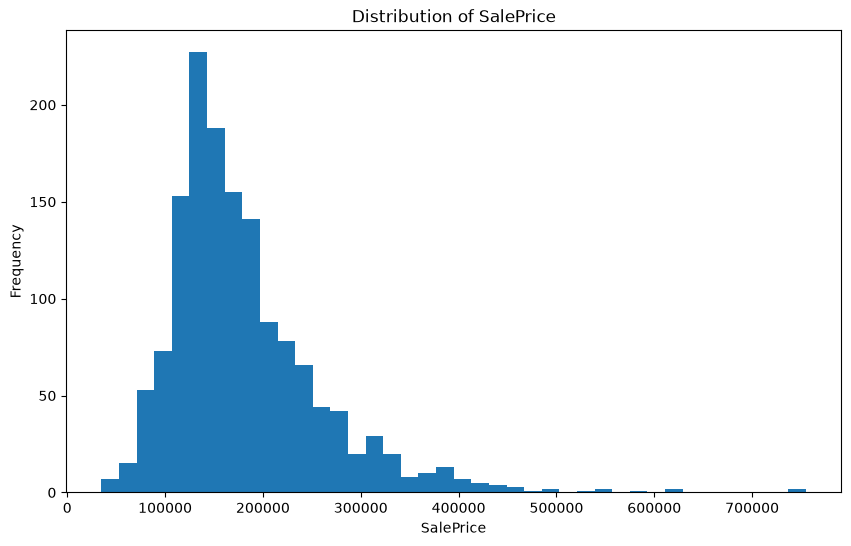

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(train_df[TARGET], bins=40)

plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")

plt.show()

### Finding

`SalePrice` is strongly right-skewed:

- Raw skewness: **1.883**
- `log1p(SalePrice)` skewness: **0.121**

The logarithmic transformation substantially reduces target skewness.

**Recommendation:** evaluate `log1p(SalePrice)` as the modeling target in a controlled CV experiment.

This is a candidate, not a final preprocessing decision. The strategy plan specifies that target choices should ultimately be judged using CV RMSLE. :contentReference[oaicite:1]{index=1}

## 10. Outlier & Anomaly Audit

Extreme observations are investigated to distinguish legitimate unusual properties from potential data-quality problems.

An observation is not removed solely because it is statistically extreme or negatively affects model performance.

In [18]:
top_sales = (
    train_df[
        [
            "Id",
            "SalePrice",
            "OverallQual",
            "GrLivArea",
            "TotalBsmtSF",
            "YearBuilt",
            "Neighborhood",
        ]
    ]
    .sort_values("SalePrice", ascending=False)
    .head(15)
)

top_sales

,Id,SalePrice,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,Neighborhood
691,692,755000,10,4316,2444,1994,NoRidge
1182,1183,745000,10,4476,2396,1996,NoRidge
1169,1170,625000,10,3627,1930,1995,NoRidge
898,899,611657,9,2364,2330,2009,NridgHt
803,804,582933,9,2822,1734,2008,NridgHt
1046,1047,556581,9,2868,1992,2005,StoneBr
440,441,555000,10,2402,3094,2008,NridgHt
769,770,538000,8,3279,1650,2003,StoneBr
178,179,501837,9,2234,2216,2008,StoneBr
798,799,485000,9,3140,1926,2008,NridgHt


### High SalePrice observations

The highest-priced houses generally have combinations of high quality, substantial living area, large basement area, recent construction, and/or desirable neighborhoods.

No obvious target corruption was established from this inspection.

**Decision:** retain these observations.

In [19]:
large_houses = (
    train_df[
        [
            "Id",
            "GrLivArea",
            "SalePrice",
            "OverallQual",
            "Neighborhood",
            "YearBuilt",
        ]
    ]
    .sort_values("GrLivArea", ascending=False)
    .head(15)
)

large_houses

,Id,GrLivArea,SalePrice,OverallQual,Neighborhood,YearBuilt
1298,1299,5642,160000,10,Edwards,2008
523,524,4676,184750,10,Edwards,2007
1182,1183,4476,745000,10,NoRidge,1996
691,692,4316,755000,10,NoRidge,1994
1169,1170,3627,625000,10,NoRidge,1995
185,186,3608,475000,10,OldTown,1892
304,305,3493,295000,7,OldTown,1880
1268,1269,3447,381000,8,Crawfor,1935
635,636,3395,200000,6,SWISU,1914
769,770,3279,538000,8,StoneBr,2003


In [20]:
suspicious_ids = [524, 1299]

area_check = train_df[
    train_df["Id"].isin(suspicious_ids)
][[
    "Id",
    "GrLivArea",
    "1stFlrSF",
    "2ndFlrSF",
    "SalePrice",
    "OverallQual",
    "Neighborhood",
]]

area_check["CalculatedGrLivArea"] = (
    area_check["1stFlrSF"] + area_check["2ndFlrSF"]
)

area_check["Difference"] = (
    area_check["GrLivArea"] -
    area_check["CalculatedGrLivArea"]
)

area_check

,Id,GrLivArea,1stFlrSF,2ndFlrSF,SalePrice,OverallQual,Neighborhood,CalculatedGrLivArea,Difference
523,524,4676,3138,1538,184750,10,Edwards,4676,0
1298,1299,5642,4692,950,160000,10,Edwards,5642,0


### Finding

Two observations are particularly unusual:

| Id | GrLivArea | SalePrice | OverallQual |
|---:|---:|---:|---:|
| 524 | 4,676 | $184,750 | 10 |
| 1299 | 5,642 | $160,000 | 10 |

Both have internally consistent living-area calculations:

`GrLivArea = 1stFlrSF + 2ndFlrSF`

Therefore, no obvious arithmetic/data-entry inconsistency was established.

**Decision:** retain these observations.

They will be treated as potentially influential observations and can be revisited during later error analysis.

# Final Data Audit Report

## 1. Dataset Structure

- Train: 1,460 rows × 81 columns
- Test: 1,459 rows × 80 columns
- Target: `SalePrice`
- Common features: 80
- Duplicate rows: none
- Duplicate IDs: none
- Train IDs: 1–1460
- Test IDs: 1461–2919
- No overlapping IDs between train and test.

## 2. Missing Values

Missing values are not treated uniformly because the dataset documentation shows
that some missing values represent the absence of a property feature.

### Structural missingness

The following missing values represent the absence of the corresponding feature:

- `PoolQC` → no pool
- `MiscFeature` → no miscellaneous feature
- `Alley` → no alley access
- `Fence` → no fence
- `FireplaceQu` → no fireplace
- `Garage*` → no garage
- `Bsmt*` → no basement
- `MasVnrType` / `MasVnrArea` → generally no masonry veneer

These will be handled using domain-aware representations rather than generic
imputation.

### Other missing values

- `LotFrontage` → investigate neighborhood-based imputation.
- `Electrical` → isolated missing value; evaluate an appropriate categorical
  imputation strategy.
- `MasVnrArea` → investigate together with `MasVnrType`.
- `GarageYrBlt` → handle according to garage presence and evaluate an appropriate
  imputation strategy.

## 3. Data Quality Findings

- No duplicate rows were found.
- No duplicate IDs were found.
- `MasVnrType` has five observations where the type is missing but
  `MasVnrArea > 0`; these cases require careful preprocessing rather than
  blindly assuming absence.
- `GarageYrBlt` contains one highly suspicious test value (`2207`).
  It will be flagged and its treatment will be evaluated during preprocessing.
- `GarageYrBlt > YearBuilt` will not automatically be treated as invalid because
  a garage may be constructed after the original house.

## 4. Numerical Distribution Audit

Train and test distributions are broadly similar for the major structural
features such as:

- `OverallQual`
- `OverallCond`
- `YearBuilt`
- `YearRemodAdd`
- `GrLivArea`
- `TotalBsmtSF`
- `GarageCars`
- `GarageArea`

Some sparse features show larger percentage differences in their means, but
these differences are influenced by their large number of zero values.

A small number of test observations fall outside the training range for some
numerical features. These will be investigated where they represent potential
data-quality issues.

`Id` is treated as an identifier and not as a conventional numerical feature.

## 5. Target Analysis

`SalePrice` is strongly right-skewed:

- Mean: 180,921
- Median: 163,000
- Skewness: 1.88
- Kurtosis: 6.54

Applying `log1p` reduces the skewness to approximately 0.12.

Because the competition metric is RMSLE, `log1p(SalePrice)` will be evaluated
as the primary target transformation during modeling.

## 6. Outlier Findings

Several observations have unusually large `GrLivArea` values.

Two observations (`Id` 524 and 1299) have extremely large living areas but
unusually low sale prices relative to their size.

These observations will not be removed during preprocessing solely because
they appear anomalous. Their influence will instead be evaluated through
cross-validation and later error analysis.

## 7. Preprocessing Plan

Based on this audit, preprocessing will focus on:

1. Domain-aware handling of structural missing values.
2. Appropriate imputation for genuinely unknown values.
3. Consistent categorical encoding.
4. Investigation and controlled handling of suspicious numerical values.
5. Evaluation of skewed numerical feature transformations.
6. `log1p` transformation of the target.
7. Keeping all preprocessing inside a reproducible pipeline to prevent leakage.

No observation or feature will be removed solely because it appears unusual.

All important preprocessing decisions will be evaluated using the fixed
cross-validation framework and the competition's RMSLE metric.

## 8. Items Requiring Validation

The following decisions should be treated as experiments rather than fixed
assumptions:

- Structural missing-value representation.
- `LotFrontage` imputation strategy.
- Handling of `MasVnrType` / `MasVnrArea` inconsistencies.
- Handling of the suspicious `GarageYrBlt = 2207`.
- Numerical feature transformations.
- Domain-driven engineered features.

The best approach will be selected based on cross-validated performance,
fold stability, and error analysis.